# 05 - Stress & Curvature Operator Validation

Validates the DDG stress tensor operators (`stress_force`, `velocity_difference_tensor`)
against analytically integrated solutions over dual cells.

**Key results:**
- **Linear pressure**: `stress_force(mu=0)` matches `∫ ∇P dV` at machine precision
- **Linear velocity**: viscous force is zero (constant gradient => no diffusion)
- **Quadratic velocity (Poiseuille)**: diffusion form `(mu/|d|)*du*(d_hat·A)` is exact on symmetric Delaunay meshes
- **Poiseuille equilibrium**: pressure + viscous cancel at machine precision on symmetric meshes

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import matplotlib.pyplot as plt
from hyperct import Complex
from hyperct.ddg import compute_vd, dual_cell_polygon_2d

from ddgclib.operators.stress import stress_force, cache_dual_volumes
from ddgclib.analytical._divergence_theorem import integrated_gradient_2d

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Pressure Gradient Benchmark

Hydrostatic pressure $P(x,y) = \rho g (H - y)$ with zero velocity.
The DDG pressure force $F_p = -0.5 \sum_j (p_i + p_j) A_{ij}$ should match
the analytical $-\int_{V_i} \nabla P \, dV$ at machine precision (linear P).

Pressure Gradient Benchmark (hydrostatic)
  n_interior = 25
  max_abs_error = 2.17e-15
  mean_abs_error = 3.98e-16


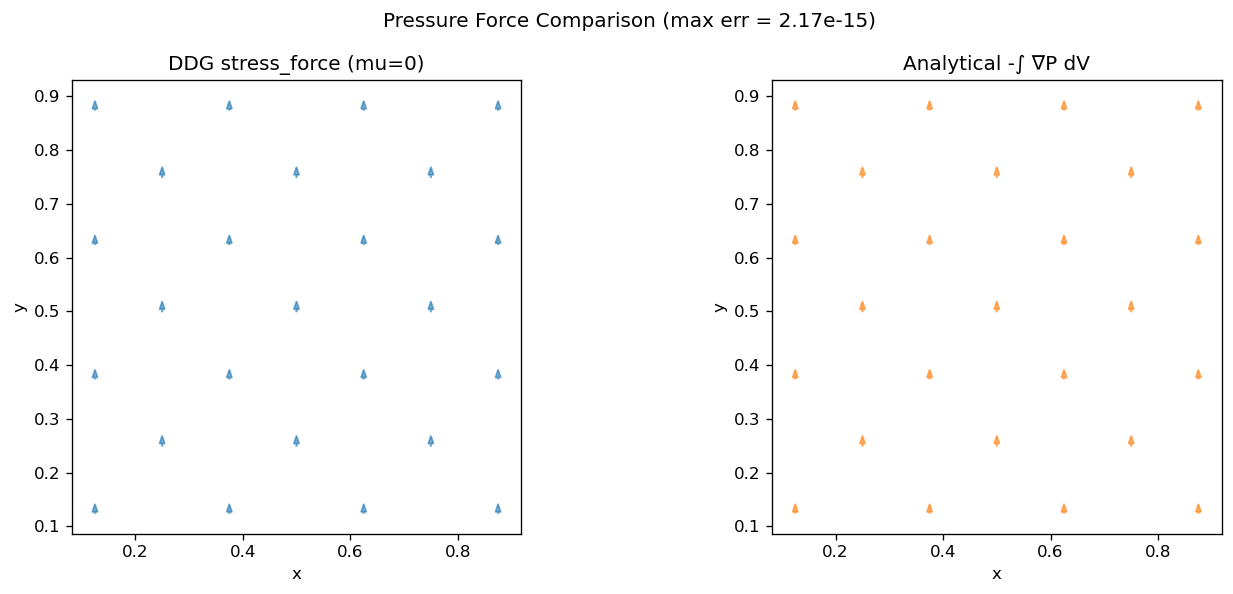

In [2]:
from benchmarks._integrated_benchmark_cases import PressureGradientBenchmark

bench_p = PressureGradientBenchmark(dim=2, n_refine=2, g=9.81, H=1.0)
summary_p = bench_p.run()

print("Pressure Gradient Benchmark (hydrostatic)")
print(f"  n_interior = {summary_p['n_interior']}")
print(f"  max_abs_error = {summary_p['max_abs_error']:.2e}")
print(f"  mean_abs_error = {summary_p['mean_abs_error']:.2e}")

# Visualize force vectors
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for v in bench_p.interior_vertices:
    vid = id(v)
    F_num = bench_p.numerical[vid]
    F_ana = bench_p.analytical[vid]
    ax1.arrow(v.x_a[0], v.x_a[1], F_num[0]*0.01, F_num[1]*0.01,
              head_width=0.01, color='tab:blue', alpha=0.6)
    ax2.arrow(v.x_a[0], v.x_a[1], F_ana[0]*0.01, F_ana[1]*0.01,
              head_width=0.01, color='tab:orange', alpha=0.6)

ax1.set_title('DDG stress_force (mu=0)')
ax2.set_title('Analytical -∫ ∇P dV')
for ax in [ax1, ax2]:
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal')
fig.suptitle(f'Pressure Force Comparison (max err = {summary_p["max_abs_error"]:.2e})')
fig.tight_layout()

## 2. Viscous Force Benchmark

Linear velocity $\mathbf{u} = [y, 0]$: viscous force is zero (constant $\nabla u$).
Quadratic $\mathbf{u} = [y^2, 0]$: diffusion form is exact on symmetric Delaunay meshes.

In [3]:
from benchmarks._integrated_benchmark_cases import ViscousFluxBenchmark

# Linear velocity: expect machine precision (zero viscous force)
bench_lin = ViscousFluxBenchmark(velocity_order=1, dim=2, n_refine=2, mu=1.0)
summary_lin = bench_lin.run()
print(f"Linear u=[y,0]:  max|F_visc| = {summary_lin['max_abs_error']:.2e}")

# Quadratic velocity on symmetric mesh
bench_quad = ViscousFluxBenchmark(velocity_order=2, dim=2, n_refine=2, mu=1.0)
summary_quad = bench_quad.run()
print(f"Quadratic u=[y²,0] (symmetric): max|F_err| = {summary_quad['max_abs_error']:.2e}")

# Quadratic on jittered mesh
bench_quad_j = ViscousFluxBenchmark(velocity_order=2, dim=2, n_refine=2, mu=1.0, seed=42)
summary_quad_j = bench_quad_j.run()
print(f"Quadratic u=[y²,0] (jittered):  max|F_err| = {summary_quad_j['max_abs_error']:.2e}")

Linear u=[y,0]:  max|F_visc| = 1.15e-16
Quadratic u=[y²,0] (symmetric): max|F_err| = 1.03e-16
Quadratic u=[y²,0] (jittered):  max|F_err| = 1.74e-01


## 3. Poiseuille Equilibrium

$\mathbf{u} = [G/(2\mu) \cdot y(D-y), 0]$, $P = -Gx$.

At equilibrium, $-\nabla P + \mu \nabla^2 \mathbf{u} = 0$.
The DDG `stress_force` should produce zero net force on symmetric meshes.

Poiseuille Equilibrium (symmetric mesh)
  max|F| = 3.56e-17
  mean|F| = 1.02e-17


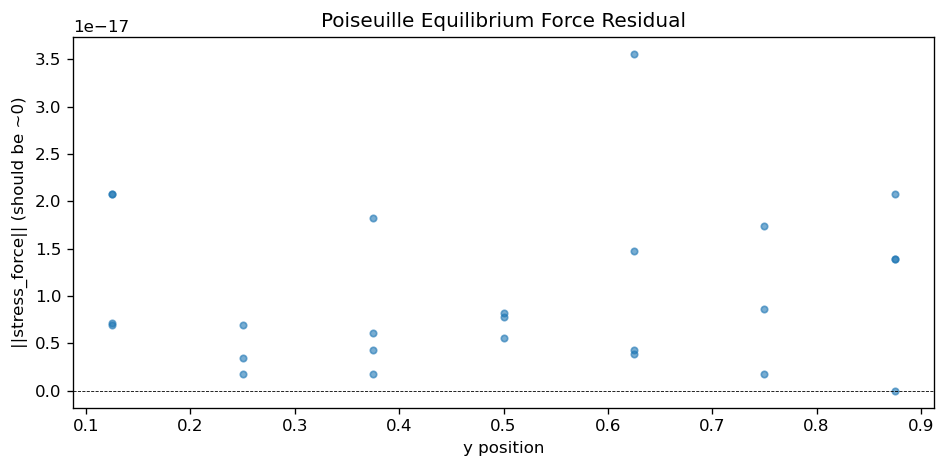

In [4]:
from benchmarks._integrated_benchmark_cases import PoiseuilleBenchmark

# Symmetric mesh: exact cancellation expected
bench_pois = PoiseuilleBenchmark(dim=2, n_refine=2, mu=1.0, G=1.0, D=1.0)
bench_pois.build_mesh()
bench_pois.compute_numerical()

F_norms = [np.linalg.norm(bench_pois.numerical[id(v)]) for v in bench_pois.interior_vertices]
y_pos = [v.x_a[1] for v in bench_pois.interior_vertices]

print(f"Poiseuille Equilibrium (symmetric mesh)")
print(f"  max|F| = {max(F_norms):.2e}")
print(f"  mean|F| = {np.mean(F_norms):.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(y_pos, F_norms, s=15, alpha=0.6)
ax.set_xlabel('y position')
ax.set_ylabel('||stress_force|| (should be ~0)')
ax.set_title('Poiseuille Equilibrium Force Residual')
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0, 0))
fig.tight_layout()

## 4. Convergence Table

Summary of all stress benchmarks across refinement levels.

In [5]:
benchmarks_list = [
    ("PressureGradient (symmetric)", PressureGradientBenchmark, dict(g=9.81, H=1.0)),
    ("PressureGradient (jittered)", PressureGradientBenchmark, dict(g=9.81, H=1.0, seed=42)),
    ("ViscousLinear (symmetric)", ViscousFluxBenchmark, dict(velocity_order=1, mu=1.0)),
    ("ViscousQuadratic (symmetric)", ViscousFluxBenchmark, dict(velocity_order=2, mu=1.0)),
    ("ViscousQuadratic (jittered)", ViscousFluxBenchmark, dict(velocity_order=2, mu=1.0, seed=42)),
]

print(f"{'Benchmark':<35} {'n_ref':>5} {'n_int':>6} {'max_err':>12} {'mean_err':>12}")
print("-" * 75)

for label, BenchClass, kwargs in benchmarks_list:
    for n_ref in [1, 2, 3]:
        bench = BenchClass(dim=2, n_refine=n_ref, **kwargs)
        summary = bench.run()
        print(f"{label:<35} {n_ref:>5} {summary['n_interior']:>6} "
              f"{summary['max_abs_error']:>12.4e} {summary['mean_abs_error']:>12.4e}")

Benchmark                           n_ref  n_int      max_err     mean_err
---------------------------------------------------------------------------
PressureGradient (symmetric)            1      5   1.6674e-15   8.4998e-16
PressureGradient (symmetric)            2     25   2.1663e-15   3.9841e-16
PressureGradient (symmetric)            3    113   5.9685e-16   1.1887e-16
PressureGradient (jittered)             1      5   1.4627e-15   9.2098e-16
PressureGradient (jittered)             2     25   1.0019e-15   3.7054e-16
PressureGradient (jittered)             3    113   7.0129e-16   1.7433e-16
ViscousLinear (symmetric)               1      5   1.0577e-16   3.4604e-17
ViscousLinear (symmetric)               2     25   1.1493e-16   2.1827e-17
ViscousLinear (symmetric)               3    113   7.3095e-17   1.4149e-17
ViscousQuadratic (symmetric)            1      5   1.1280e-16   5.8385e-17
ViscousQuadratic (symmetric)            2     25   1.0323e-16   4.1689e-17
ViscousQuadratic (symmet